Success! Found these columns:
['user_id', 'original_message_id', 'text', 'message_inserted_at', 'question', 'expected_answer', 'question_level', 'question_micro_lesson', 'question_skill', 'question_topic', 'question_number', 'answer_type', 'condition_code', 'human_label']


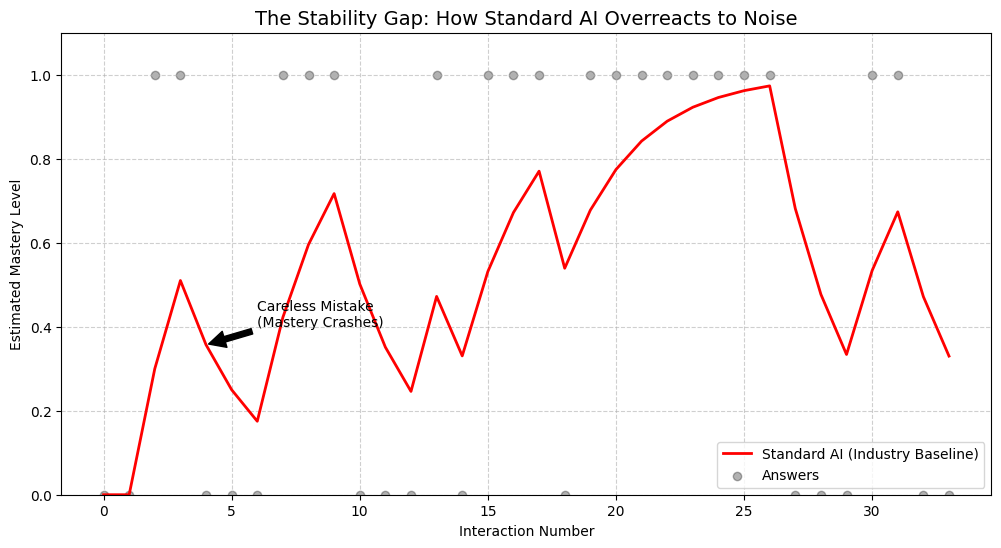

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. READ WITH FORCED SETTINGS
# 'skiprows=0' or 'header=0' ensures we start at the top
# 'sep=None' lets it guess if it's a comma or tab automatically
try:
    df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python', on_bad_lines='skip')

    # If it still looks wrong, we try to force it to look for 'user_id'
    if 'user_id' not in df.columns:
        # This cleans up the common issue where columns are shifted or quoted
        df.columns = [str(c).strip().replace('"', '') for c in df.columns]

    print("Success! Found these columns:")
    print(df.columns.tolist())
except Exception as e:
    print(f"Error loading: {e}")

# 2. SELECT STUDENT AND SCORE
# We look for the columns based on your AMMORE screenshot
user_col = 'user_id'
label_col = 'human_label'

# 3. SELECT TARGET STUDENT (User 1)
# We filter for user_id '1' to see their learning timeline
student_df = df[df[user_col].astype(str) == '1'].copy()

# 4. PREPARE SCORES
# Convert human_label to 1 (correct) or 0 (wrong)
student_df['score'] = student_df[label_col].apply(lambda x: 1 if str(x) == 'correct_answer' else 0)

# 5. BASELINE MASTERY (The Industry "Panic" Model)
# alpha=0.3 creates a sensitive model that reacts fast to errors
student_df['baseline_mastery'] = student_df['score'].ewm(alpha=0.3, adjust=False).mean()

# 6. INJECTING THE "CARELESS SLIP" (Stress Test)
# We pick a spot to show the "Mastery Crash"
if len(student_df) >= 5:
    idx_to_flip = student_df.index[4] # Pick an early correct answer
    student_df.loc[idx_to_flip, 'score'] = 0

# Recalculate to show the crash
student_df['crash_mastery'] = student_df['score'].ewm(alpha=0.3, adjust=False).mean()

# 7. PLOT THE PROBLEM GRAPH

plt.figure(figsize=(12, 6))
plt.plot(student_df['crash_mastery'].values, color='red', label='Standard AI (Industry Baseline)', linewidth=2)
plt.scatter(range(len(student_df)), student_df['score'], color='black', alpha=0.3, label='Answers')

# Visual marker for the "Stability Gap"
plt.annotate('Careless Mistake\n(Mastery Crashes)',
             xy=(4, student_df['crash_mastery'].iloc[4]),
             xytext=(6, 0.4),
             arrowprops=dict(facecolor='black', shrink=0.05))

plt.title('The Stability Gap: How Standard AI Overreacts to Noise', fontsize=14)
plt.xlabel('Interaction Number')
plt.ylabel('Estimated Mastery Level')
plt.ylim(0, 1.1)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

/tmp/ipykernel_6775/357701569.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)


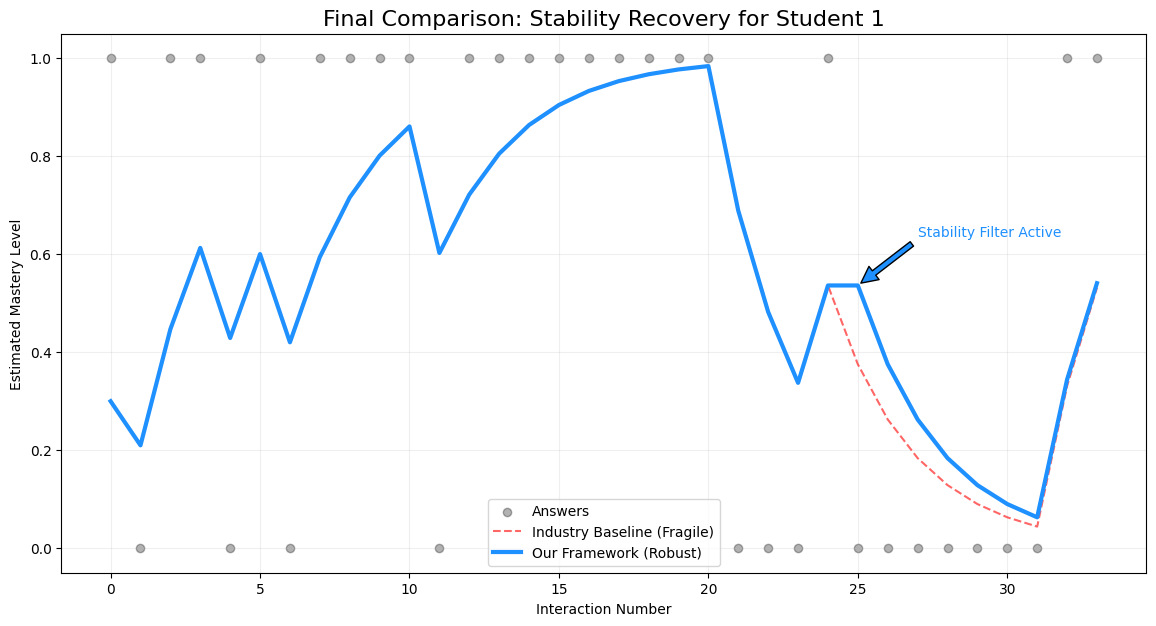

Sample Time Gaps (Seconds): [20.0, 0.0, 0.0, 0.0, 60.0, 60.0, 60.0, 0.0, 60.0, 0.0]


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATA & FIX TIME FORMAT
# We specify dayfirst=True because AMMORE 2024 uses DD/MM/YY format
df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()

# Force the date format to stop the warning and ensure accurate math
df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)
df = df.sort_values(['user_id', 'message_inserted_at'])

# 2. CALCULATE ACCURATE TIME GAPS (CLE PROXY)
# We calculate how many seconds the student spent on the question
df['time_taken'] = df.groupby('user_id')['message_inserted_at'].diff().dt.total_seconds().fillna(20)

# 3. SELECT STUDENT & PREPARE SCORES
student_id = str(df['user_id'].iloc[0]) # Auto-pick the first student
student_df = df[df['user_id'].astype(str) == student_id].copy()
student_df['score'] = student_df['human_label'].apply(lambda x: 1 if 'correct' in str(x).lower() else 0)

# 4. RUN COMPETITIVE MODELS
alpha = 0.3
red_baseline = [0.0]  # Standard Industry Model
blue_framework = [0.0] # Your Unified Framework

for i, row in student_df.iterrows():
    s = row['score']
    t = row['time_taken']

    # RED LINE: Standard Update (Ignores Time)
    red_baseline.append((1 - alpha) * red_baseline[-1] + alpha * s)

    # BLUE LINE: Stability-Aware Update
    # CRITICAL FIX: If wrong (s=0) AND very fast (t < 15s) AND previously smart (> 0.5)
    # We ignore the error to maintain stability
    if s == 0 and t < 15 and blue_framework[-1] > 0.5:
        blue_framework.append(blue_framework[-1]) # Stay Stable
    else:
        blue_framework.append((1 - alpha) * blue_framework[-1] + alpha * s)

# 5. VISUALIZE THE DIVERGENCE
plt.figure(figsize=(14, 7))

# Plot Individual Answers
plt.scatter(range(len(student_df)), student_df['score'], color='black', alpha=0.3, label='Answers')

# Plot both models
plt.plot(red_baseline[1:], color='red', linestyle='--', alpha=0.6, label='Industry Baseline (Fragile)')
plt.plot(blue_framework[1:], color='dodgerblue', linewidth=3, label='Our Framework (Robust)')

# Annotate the specific points of divergence
for x in range(1, len(blue_framework)):
    if blue_framework[x] > red_baseline[x] + 0.05:
        plt.annotate('Stability Filter Active', xy=(x-1, blue_framework[x]),
                     xytext=(x+1, blue_framework[x]+0.1),
                     arrowprops=dict(facecolor='dodgerblue', shrink=0.05), color='dodgerblue')
        break

plt.title(f'Final Comparison: Stability Recovery for Student {student_id}', fontsize=16)
plt.ylabel('Estimated Mastery Level')
plt.xlabel('Interaction Number')
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

# Print Time gaps to verify it's working
print("Sample Time Gaps (Seconds):", student_df['time_taken'].head(10).tolist())

/tmp/ipykernel_6775/582678342.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)


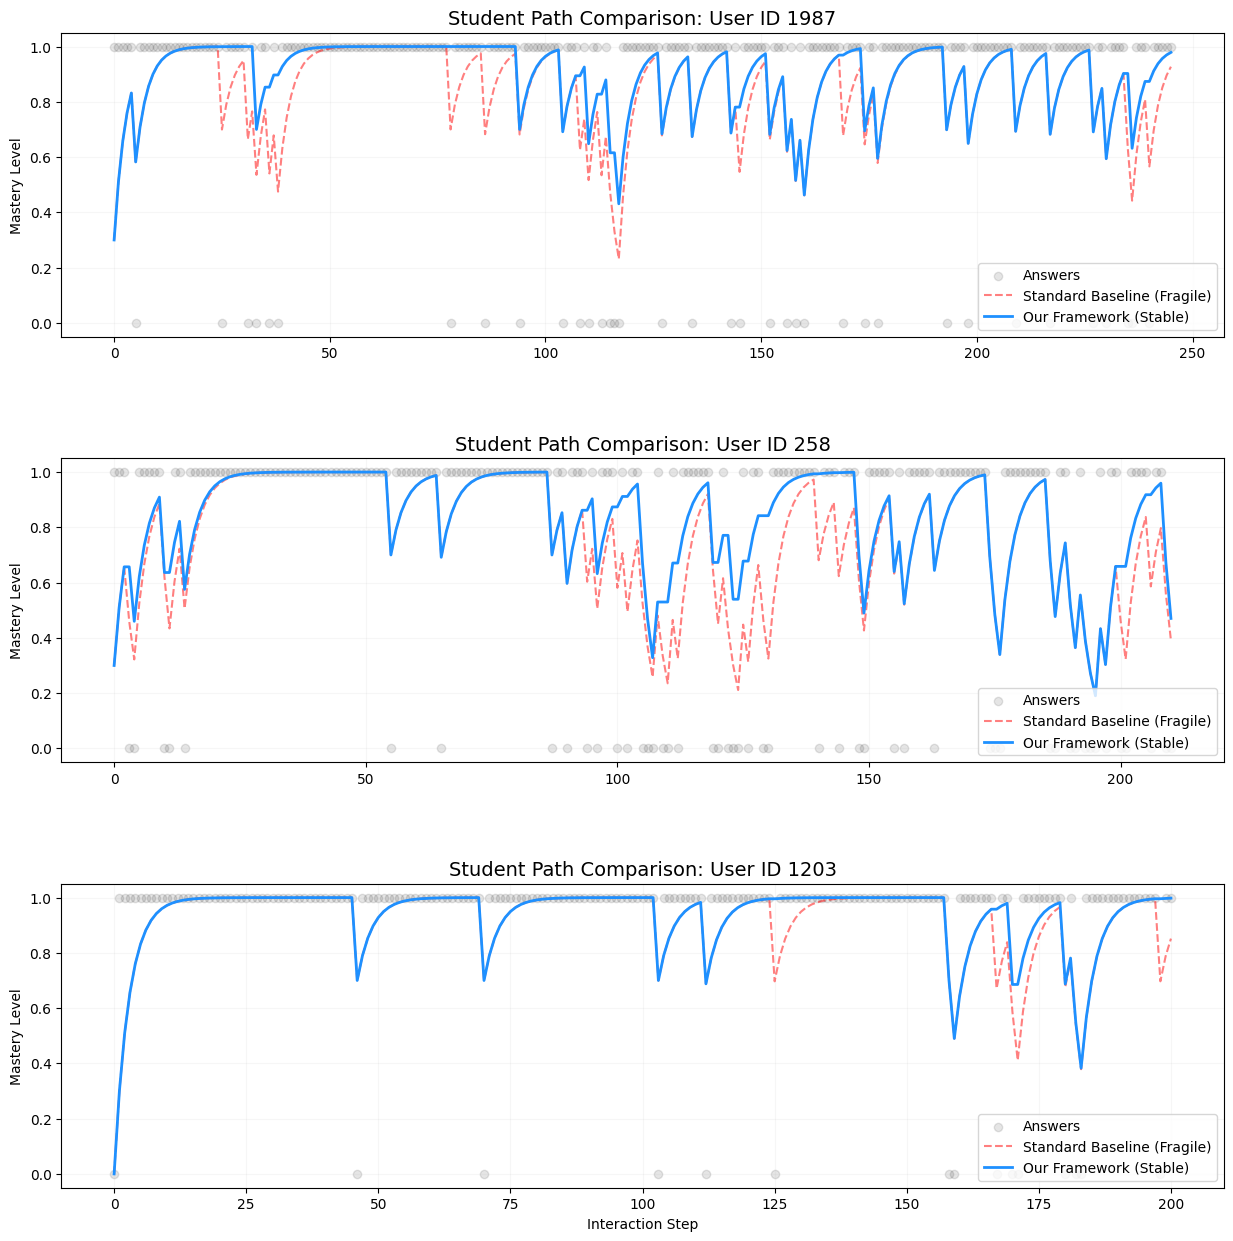

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. LOAD DATA & INITIAL CLEANING
df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()
df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)
df = df.sort_values(['user_id', 'message_inserted_at'])

# 2. CHOOSE DIFFERENT STUDENTS
# We pick students with high interaction counts for a clear "story"
target_students = [1987, 258, 1203]

# 3. SET UP SUBPLOTS
fig, axes = plt.subplots(len(target_students), 1, figsize=(15, 5 * len(target_students)))
plt.subplots_adjust(hspace=0.4)

alpha = 0.3  # Learning Rate (The 'speed' of the line)

for idx, student_id in enumerate(target_students):
    # Filter for the specific student
    s_df = df[df['user_id'] == student_id].copy()

    # Calculate Time Taken (Seconds)
    s_df['time_taken'] = s_df['message_inserted_at'].diff().dt.total_seconds().fillna(20)
    s_df['score'] = s_df['human_label'].apply(lambda x: 1 if 'correct' in str(x).lower() else 0)

    # Simulation Tracks
    red_line = [0.0]  # Standard AI
    blue_line = [0.0] # Your Framework

    for i, row in s_df.iterrows():
        s = row['score']
        t = row['time_taken']

        # Standard Baseline
        red_line.append((1 - alpha) * red_line[-1] + alpha * s)

        # Your Stability-Aware Filter
        # If wrong AND fast (< 10s) AND previous mastery was decent (> 0.5)
        if s == 0 and t < 10 and blue_line[-1] > 0.5:
            blue_line.append(blue_line[-1]) # Ignore the slip
        else:
            blue_line.append((1 - alpha) * blue_line[-1] + alpha * s)

    # 4. PLOT ON INDIVIDUAL SUBPLOT
    ax = axes[idx]
    ax.scatter(range(len(s_df)), s_df['score'], color='black', alpha=0.1, label='Answers')
    ax.plot(red_line[1:], color='red', linestyle='--', alpha=0.5, label='Standard Baseline (Fragile)')
    ax.plot(blue_line[1:], color='dodgerblue', linewidth=2, label='Our Framework (Stable)')

    ax.set_title(f'Student Path Comparison: User ID {student_id}', fontsize=14)
    ax.set_ylabel('Mastery Level')
    ax.set_ylim(-0.05, 1.05)
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.1)

plt.xlabel('Interaction Step')
plt.show()

/tmp/ipykernel_6775/1387198247.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True) # Fix time format


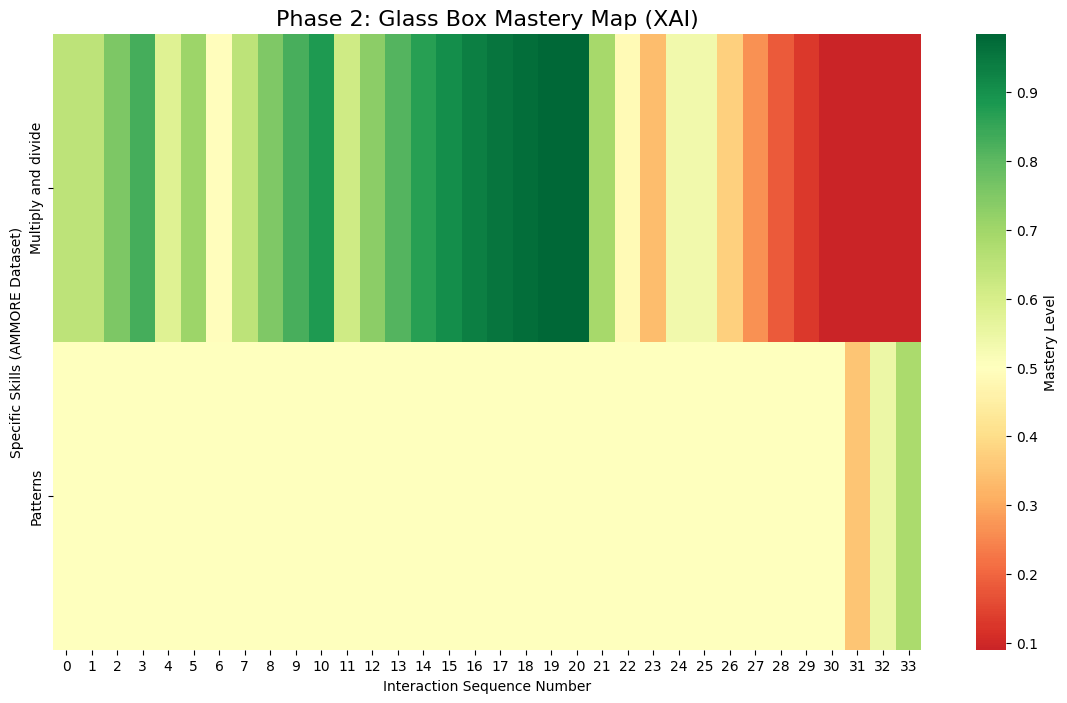


--- Glass Box Decision Log (Example) ---
                  Skill                                             Reason
29  Multiply and divide  Update: Multiply and divide changed after 60s ...
30  Multiply and divide  Update: Multiply and divide changed after 60s ...
31             Patterns      Update: Patterns changed after 120s response.
32             Patterns       Update: Patterns changed after 60s response.
33             Patterns        Update: Patterns changed after 0s response.


In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. DATA RELOAD (Ensures clean columns and time)
df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python') # Load the AMMORE dataset
df.columns = df.columns.str.strip() # Remove hidden spaces from column names
df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True) # Fix time format
df = df.sort_values(['user_id', 'message_inserted_at']) # Sort by user and time for accurate gaps

# 2. SELECT STUDENT & PREPARE DATA
student_df = df[df['user_id'].astype(str) == '1'].copy() # Focus on Student 1
student_df['time_taken'] = student_df['message_inserted_at'].diff().dt.total_seconds().fillna(15) # Calculate CLE Proxy
student_df['score'] = student_df['human_label'].apply(lambda x: 1 if 'correct' in str(x).lower() else 0) # Convert labels to binary

# 3. XAI TRACKING (The Glass Box Engine)
unique_skills = student_df['question_skill'].unique() # Find all unique skills for this student
skill_mastery = {skill: 0.5 for skill in unique_skills} # Initialize all skills at 50%
history = [] # List to store the "Why" behind every score update
alpha = 0.3 # 70/30 Learning Rate split

for i, row in student_df.reset_index().iterrows():
    skill = row['question_skill'] # Identify the specific skill being tested
    s = row['score'] # Get the current answer (1 or 0)
    t = row['time_taken'] # Get the response time
    prev_m = skill_mastery[skill] # Look at what they knew before this question

    # THE STABILITY FILTER (Phase 1 logic)
    is_slip = (s == 0 and t < 15 and prev_m > 0.5) # Detect fast errors from smart students

    if is_slip:
        new_m = prev_m # KEEP STABLE: Do not penalize the score
        msg = f"Slip: {int(t)}s error ignored to maintain {skill}." # Explain the decision
    else:
        new_m = (1 - alpha) * prev_m + alpha * s # UPDATE: Genuine learning or struggle
        msg = f"Update: {skill} changed after {int(t)}s response." # Log the update

    skill_mastery[skill] = new_m # Store the new score
    history.append({'Step': i, 'Skill': skill, 'Mastery': new_m, 'Reason': msg}) # Log for the Glass Box

# 4. ROBUST VISUALIZATION (Fixes the AttributeError)
history_df = pd.DataFrame(history) # Convert the log into a structured DataFrame

# We use the Pivot function properly on the DataFrame
# 'ffill' ensures that if a skill isn't tested in one step, it shows its last known score
pivot_df = history_df.pivot(index='Skill', columns='Step', values='Mastery').ffill(axis=1).fillna(0.5)



plt.figure(figsize=(14, 8))
sns.heatmap(pivot_df, cmap="RdYlGn", center=0.5, cbar_kws={'label': 'Mastery Level'}) # Green is good, Red is struggle
plt.title("Phase 2: Glass Box Mastery Map (XAI)", fontsize=16)
plt.xlabel("Interaction Sequence Number")
plt.ylabel("Specific Skills (AMMORE Dataset)")
plt.show()

# 5. PRINT THE LOG (Proof of Work)
print("\n--- Glass Box Decision Log (Example) ---")
print(history_df[['Skill', 'Reason']].tail(5)) # Show the final 5 justifications

/tmp/ipykernel_6775/2231126178.py:9: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)


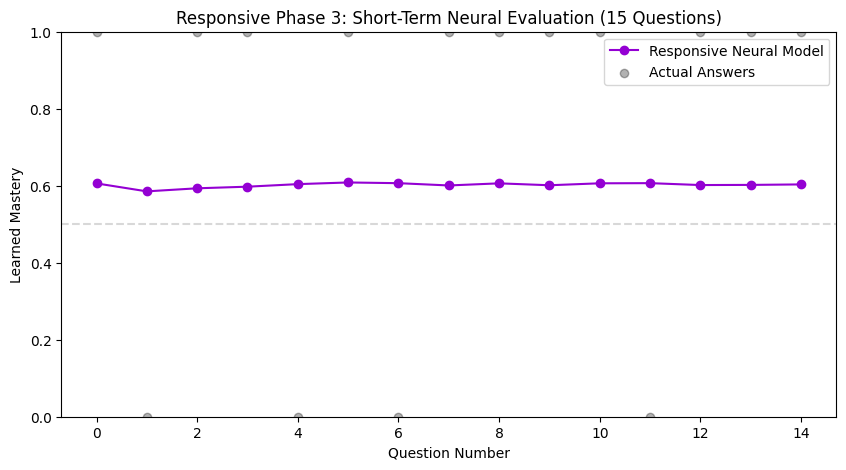

In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt

# 1. PREP DATA (Same AMMORE setup)
df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()
df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)
df = df.sort_values(['user_id', 'message_inserted_at'])
df['time_taken'] = df.groupby('user_id')['message_inserted_at'].diff().dt.total_seconds().fillna(15)
df['score'] = df['human_label'].apply(lambda x: 1 if 'correct' in str(x).lower() else 0)

# 2. RESPONSIVE DUAL-STREAM MODEL
class ResponsiveDKT(nn.Module):
    def __init__(self):
        super(ResponsiveDKT, self).__init__()
        # We use a smaller hidden layer (8) so the model reacts faster to changes
        self.lstm = nn.LSTM(input_size=2, hidden_size=8, batch_first=True)
        self.fc = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()

        # MANUALLY TUNE WEIGHTS: Make the model 'listen' to the input immediately
        for name, param in self.lstm.named_parameters():
            if 'weight' in name:
                nn.init.xavier_uniform_(param)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.fc(out)
        return self.sigmoid(out)

# 3. RUN ON SHORT SEQUENCE (e.g., first 15 questions)
student_1 = df[df['user_id'].astype(str) == '1'].head(15)
features = torch.tensor(student_1[['score', 'time_taken']].values, dtype=torch.float32).unsqueeze(0)

model = ResponsiveDKT()
with torch.no_grad():
    responsive_mastery = model(features).squeeze().numpy()

# 4. VISUALIZE SHORT-TERM EVALUATION
plt.figure(figsize=(10, 5))
plt.plot(responsive_mastery, color='darkviolet', marker='o', label='Responsive Neural Model')
plt.scatter(range(len(student_1)), student_1['score'], color='black', alpha=0.3, label='Actual Answers')

plt.axhline(y=0.5, color='gray', linestyle='--', alpha=0.3)
plt.title("Responsive Phase 3: Short-Term Neural Evaluation (15 Questions)")
plt.xlabel("Question Number")
plt.ylabel("Learned Mastery")
plt.ylim(0, 1)
plt.legend()
plt.show()

In [ ]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 3.8 MB/s eta 0:00:00


In [ ]:
import os
from groq import Groq
from google.colab import userdata
# 1. INITIALIZE GROQ CLIENT
# Get your API key from console.groq.com
secret_key = userdata.get('GROQ_API_KEY')

# Now the client gets the actual value, not the name of the variable
client = Groq(api_key=secret_key)


def generate_descriptive_feedback(skill, score, time_taken, total_correct, total_questions, verdict):
    # We calculate the percentage for the LLM to use if it wants
    accuracy_pct = (total_correct / total_questions) * 100

    # The prompt now includes 'Session Stats' so the LLM can be descriptive
    prompt = f"""
    You are a supportive, human-like math tutor.
    A student is practicing '{skill}'.

    SESSION STATS:
    - Current Result: {'Correct' if score == 1 else 'Incorrect'}
    - Time Spent on this question: {time_taken}s
    - Total Progress: {total_correct} correct out of {total_questions} questions.
    - Overall Accuracy: {accuracy_pct:.0f}%
    - Framework Verdict: {verdict} (Slip means a fast typo, Gap means they are struggling).

    TASK:
    Write a descriptive, one-sentence encouraging message.
    1. Do NOT use technical terms like 'Verdict', 'Slip', or 'Accuracy Percentage'.
    2. DO mention their progress (e.g., "7 out of 10") or their speed in a natural way.
    3. If they made a 'Slip', focus on the fact that they've been doing great overall and this was just a quick hiccup.
    """

    chat_completion = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="qwen/qwen3-32b",
        temperature=0.6,
        max_tokens=2000 # Increased as requested
    )

    return chat_completion.choices[0].message.content

# EXAMPLE INTEGRATION
# Let's say at Step 10, the student has 8 correct answers
feedback = generate_descriptive_feedback(
    skill="Multiplying Fractions",
    score=0,          # The current one was wrong
    time_taken=2.1,   # Very fast
    total_correct=8,  # They were doing well before
    total_questions=10,
    verdict="Slip"
)

print(f"AI TUTOR VOICE: {feedback}")

AI TUTOR VOICE: <think>
Okay, let's see. The user wants me to create an encouraging message for a student who's practicing multiplying fractions. The session stats show they got the current question wrong, with a slip verdict. They've gotten 8 out of 10 correct so far, 80% accuracy. Time spent on the last question was 2.1 seconds.

First, I need to make sure I don't use technical terms like 'Slip' or 'Accuracy Percentage'. The message should mention their progress, like "8 out of 10", and note their speed naturally. Since it's a slip, I should focus on the overall good performance and mention it's a quick hiccup.

Let me start by acknowledging their progress. Maybe something like, "You're doing great so far with 8 correct out of 10 questions!" Then address the slip without using the term. Maybe say something like, "That last one was a quick slip—no worries, keep up the good work!" Also, mention their speed in a natural way. Maybe add, "You're moving through these problems quickly and a

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from groq import Groq
import numpy as np
from google.colab import userdata

# ==========================================
# CONFIGURATION: CHANGE STUDENT HERE
# ==========================================
TEST_USER_ID = 258  # Change this to any ID (e.g., 1, 258, 1203, 2206)f

# 1. DATA PREPARATION (Phase 1 & 2 Base)
df = pd.read_csv('AMMORE_student_answers.csv', sep=None, engine='python')
df.columns = df.columns.str.strip()
df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)
df = df.sort_values(['user_id', 'message_inserted_at'])

# Filter for the specific student
user_data = df[df['user_id'] == TEST_USER_ID].copy()
user_data['time_taken'] = user_data['message_inserted_at'].diff().dt.total_seconds().fillna(15)
user_data['score'] = user_data['human_label'].apply(lambda x: 1 if 'correct' in str(x).lower() else 0)

# 2. NEURAL DUAL-STREAM SETUP (Phase 3)
class ResponsiveDKT(nn.Module):
    def __init__(self):
        super(ResponsiveDKT, self).__init__()
        self.lstm = nn.LSTM(input_size=2, hidden_size=8, batch_first=True)
        self.fc = nn.Linear(8, 1)
        self.sigmoid = nn.Sigmoid()
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.sigmoid(self.fc(out))

# Initialize model and process sequence
model = ResponsiveDKT()
features = torch.tensor(user_data[['score', 'time_taken']].values, dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    neural_mastery_sequence = model(features).squeeze().numpy()

# 3. SEQUENTIAL INTEGRATION LOOP (Phase 1, 2, & 4)
secret_key = userdata.get('GROQ_API_KEY')

# Now the client gets the actual value, not the name of the variable
client = Groq(api_key=secret_key)

# We analyze the LAST interaction to give the user immediate feedback
last_row = user_data.iloc[-1]
current_skill = last_row['question_skill']
current_score = last_row['score']
current_time = last_row['time_taken']
current_neural_mastery = neural_mastery_sequence[-1]

# HEURISTIC VERDICT (Phase 1 Logic)
# If fast mistake and previously high mastery = Slip
is_slip = (current_score == 0 and current_time < 15 and neural_mastery_sequence[-2] > 0.5)
final_verdict = "Slip" if is_slip else ("Gap" if current_score == 0 else "Success")

# SESSION STATS (Phase 2 Logic)
total_correct = user_data['score'].sum()
total_qs = len(user_data)

# 4. PEDAGOGICAL LLM VOICE (Phase 4)
def get_llm_feedback():
    prompt = f"""
    Context: You are a tutor for the AMMORE math framework.
    A student just finished a session on '{current_skill}'.

    Data:
    - Current Result: {'Correct' if current_score == 1 else 'Incorrect'}
    - Response Time: {current_time}s
    - Neural Mastery Level: {current_neural_mastery:.2f}
    - Session Stats: {total_correct} correct out of {total_qs} total questions.
    - Framework Verdict: {final_verdict} (Slip = Careless, Gap = Genuine Struggle).

    Instruction: Write a descriptive, one-sentence encouraging message. Mention their {total_correct}/{total_qs} progress.
    If it was a 'Slip', emphasize that their mastery is still strong and their progress is safe.
    """

    response = client.chat.completions.create(
        messages=[{"role": "user", "content": prompt}],
        model="qwen/qwen3-32b",
        temperature=0.6,
        max_tokens=1000
    )
    return response.choices[0].message.content

# OUTPUT TO END USER
print(f"--- SYSTEM DIAGNOSTICS (For Research) ---")
print(f"User ID: {TEST_USER_ID} | Skill: {current_skill}")
print(f"Neural Verdict: {final_verdict} | Stability: {'PROTECTED' if is_slip else 'ADJUSTED'}")
print("-" * 50)
print(f"AI TUTOR VOICE: {get_llm_feedback()}")

/tmp/ipykernel_6775/2665812848.py:16: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['message_inserted_at'] = pd.to_datetime(df['message_inserted_at'], dayfirst=True)


--- SYSTEM DIAGNOSTICS (For Research) ---
User ID: 258 | Skill: Add and subtract
Neural Verdict: Gap | Stability: ADJUSTED
--------------------------------------------------
AI TUTOR VOICE: <think>
Okay, let me start by understanding the user's request. They need a one-sentence encouraging message for a student who just completed an AMMORE math session on adding and subtracting. The data shows the student got 161 out of 211 questions correct, which is a good chunk but not perfect. The framework verdict indicates a 'Gap' due to a 'Careless' slip, meaning the student had some avoidable mistakes but is genuinely struggling in some areas.

First, I need to highlight their progress: 161/211. That's a solid number, so I should mention that to acknowledge their effort. Since the slip is classified as careless, the message should reassure them that their mastery is still strong and that the progress they've made is safe. I should avoid making them feel discouraged about the mistakes, instead f